# Модель для прогнозирования клика на рекламный баннер поситителей сайта

Цели и задачи проекта:
  1. Ознакомиться с данными
  2. Проверить их корректность и провести предобработку
  3. Провести исследовательский анализ данных
  4. Обучить, протестировать и выбрать лучшую модель бинарной классификации
  5. Откалибровать полученную модель

# Постановка задачи машинного обучения

  - Необходимо решить задачу "обучения с учителем"
  - Целевой переменной явлется бинарная переменная 'click', информирующая о переходе по рекламному баннеру
  - Основной метрикой качества явлется Precision-Recall AUC (PR AUC), Log Loss и Оценка Бриера

# Структура проекта

Данное исследование разделим на несколько частей.
  1. [Изучение файлов с данными, получение общей информации, загрузка библиотек](#1)
  2. [Исследовательский анализ данных (EDA)](#2)
  3. [Разделение данных на выборки](#3)
  4. [Предобработка данных](#4)
  5. [Отбор признаков](#5)
  6. [Обучение базовой модели](#6)
  7. [Подбор гиперпараметров](#7)
  8. [Финальная модель](#8)
  9. [Калибровка модели](#9)
  10. [Финальный отчёт и выводы](#10)
  11. [Калибровка модели](#11)
  12. [Сохранение модели для продакшена](#12)

<a id='1'></a>
## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [1]:
!pip install phik -q
# для импорта TargetEncoder
!pip install --upgrade scikit-learn -q

In [2]:
from phik import phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import log_loss, average_precision_score, make_scorer, f1_score, brier_score_loss, roc_auc_score
from sklearn.metrics import precision_score, fbeta_score, roc_curve, recall_score, precision_recall_curve
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SequentialFeatureSelector as SFS
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from time import time
import joblib

In [3]:
# !pip freeze > requirements.txt

In [4]:
RANDOM_SEED = 42

In [5]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

In [7]:
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


Выводы по выгруженным данным:
  - Датафрем представлен 50_000 строками и 34 столбцами в которых содержится информация относительно сайтов и пользователей этих сайтов
  - В данных содержатся столбцы с машинно-сгенерированные признаки (ml_feature) и группы анонимизированных признаков, описывающих параметры аукциона (C14-C21)

<a id='2'></a>
## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

In [8]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [9]:
# Преобразуем в дататайм формат
df['hour'] = pd.to_datetime(df['hour'], format='%y%m%d%H')

# Делим столбец со временем и датой на 2 отдальных
df['date'] = df['hour'].dt.date
df['hour'] = df['hour'].dt.hour

print(f"Минимальная дата: {min(df['date'])}")
print(f"Максимальная дата: {max(df['date'])}")
print(f"Количество дней за которые представлены данные: {(max(df['date']) - min(df['date'])).days}")

Минимальная дата: 2014-10-21
Максимальная дата: 2014-10-30
Количество дней за которые представлены данные: 9


In [10]:
print('Столбцы с большим количеством уникальных значений:\n')
counter = 0
for column in df.drop(columns=['ml_feature_1', 'ml_feature_3', 'ml_feature_5',
                               'ml_feature_6', 'ml_feature_8', 'ml_feature_9',
                               'ml_feature_10']).columns:
    nunique = df[column].nunique()
    if nunique > 300:
        counter += 1
        print(f"{column} : {nunique}")
        
print(f"\nКоличество столбцов: {counter}")

print()
print('*' * 50)
print()

print('Столбцы с малым количеством уникальных значений:\n')
counter = 0
for column in df.columns:
    nunique = df[column].nunique()
    if nunique <= 300:
        counter += 1
        print(f"{column} : {nunique}")
        
print(f"\nКоличество столбцов: {counter}")

Столбцы с большим количеством уникальных значений:

id : 50000
site_id : 1160
site_domain : 1013
app_id : 976
device_id : 8580
device_ip : 41455
device_model : 2521
C14 : 1497
C17 : 387

Количество столбцов: 9

**************************************************

Столбцы с малым количеством уникальных значений:

click : 2
hour : 24
C1 : 7
banner_pos : 7
site_category : 18
app_domain : 67
app_category : 22
device_type : 4
device_conn_type : 4
C15 : 8
C16 : 9
C18 : 4
C19 : 64
C20 : 149
C21 : 59
ml_feature_2 : 5
ml_feature_4 : 2
ml_feature_7 : 3
date : 10

Количество столбцов: 19


Удаление ненужных столбцов:
  - id : не может оказывать влияние на целевую переменную
  - device_ip : не может оказывать влияние на целевую переменную
  - date : данные предоставлены всего за 9 дней - этого недостаточно чтобы делать выводы
  - site_id : не может оказывать влияние на целевую переменную
  - site_domain : не может оказывать влияние на целевую переменную
  - device_model : не может оказывать влияние на целевую переменную
  - device_id : не может оказывать влияние на целевую переменную
  - app_id : не может оказывать влияние на целевую переменную

In [11]:
cols_for_del = ['id', 'device_ip', 'date', 'site_id',
                'site_domain', 'device_model', 'device_id',
               'app_id']

df = df.drop(columns=cols_for_del)

In [12]:
categorial_features = {
                       'site_category' : 'тематическая категория веб-сайта',
                       'app_domain' : 'домен рекламируемого приложения',
                       'app_category' : 'категория рекламируемого приложения',
                       'ml_feature_2' : 'ml_feature_2',
                       'ml_feature_7' : 'ml_feature_7',
                       'click' : 'Был ли клик по рекламе'
                      }

discret_features = {
    'hour' : 'Час, в который был показан баннер',
    'banner_pos' : 'позиция баннера на веб-странице',
    'device_type' : 'тип устройства пользователя',
    'device_conn_type' : 'тип сетевого соединения устройства',
    'C1' : 'Анонимизированный признак, характеризующий контекст показа',
    'C15' : 'анонимизированный признак C15',
    'C16' : 'анонимизированный признак C16',
    'C18' : 'анонимизированный признак C18',
    'C19' : 'анонимизированный признак C19',
    'C21' : 'анонимизированный признак C21',
    'ml_feature_4' : 'ml_feature_4'
}

numeric_features = {
    'C14' : 'анонимизированный признак C14',
    'C17' : 'анонимизированный признак C17',
    'C20' : 'анонимизированный признак C20',
    'ml_feature_1' : 'ml_feature_1',
    'ml_feature_3' : 'ml_feature_3',
    'ml_feature_5' : 'ml_feature_5',
    'ml_feature_6' : 'ml_feature_6',
    'ml_feature_8' : 'ml_feature_8',
    'ml_feature_9' : 'ml_feature_9',
    'ml_feature_10' : 'ml_feature_10'
}

In [13]:
df.head()

,click,hour,C1,banner_pos,site_category,app_domain,app_category,device_type,device_conn_type,C14,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1,0,1005,1,f028772b,7801e8d9,07d7df22,1,0,17614,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,0,0,1005,0,28905ebd,7801e8d9,07d7df22,1,0,15701,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,0,0,1005,0,f028772b,7801e8d9,07d7df22,1,0,17914,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,0,0,1005,0,50e219e0,d9b5648e,0f2161f8,1,0,21611,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,0,0,1005,0,28905ebd,7801e8d9,07d7df22,1,0,15702,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


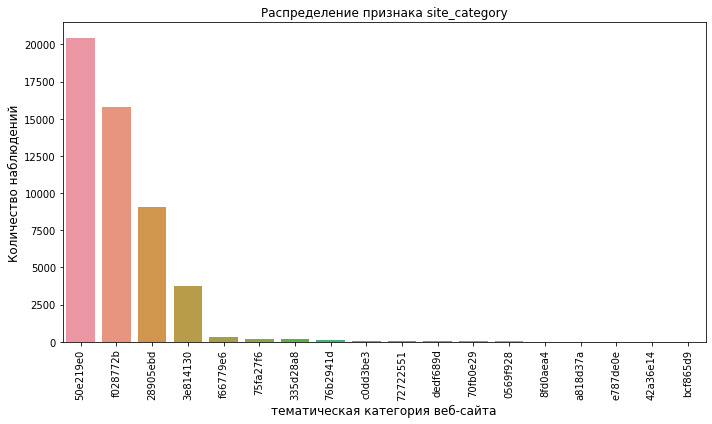

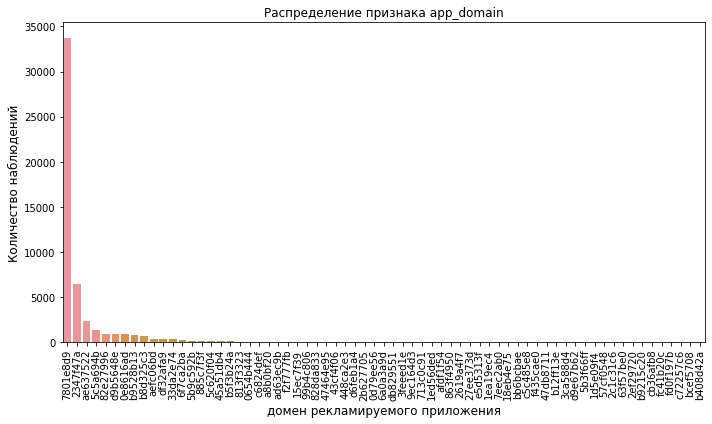

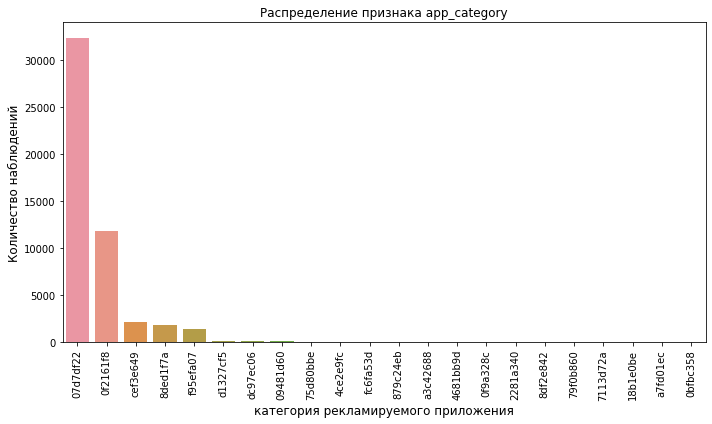

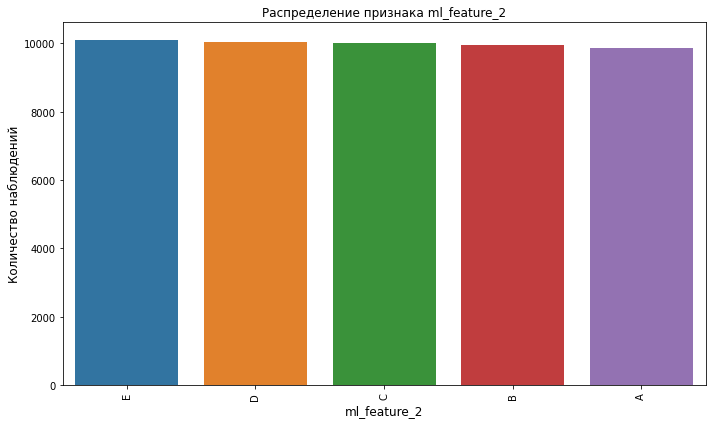

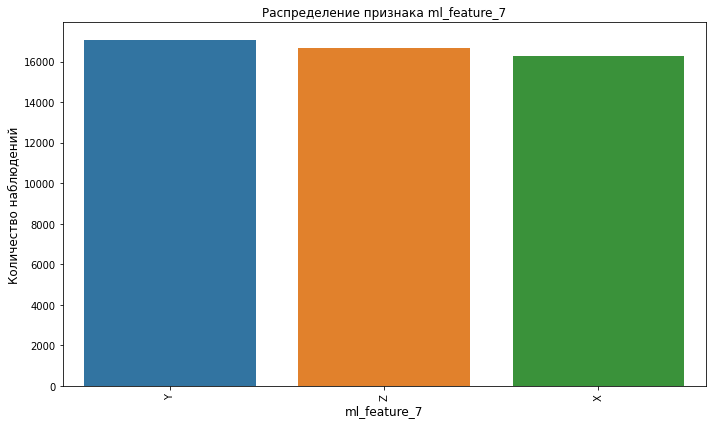

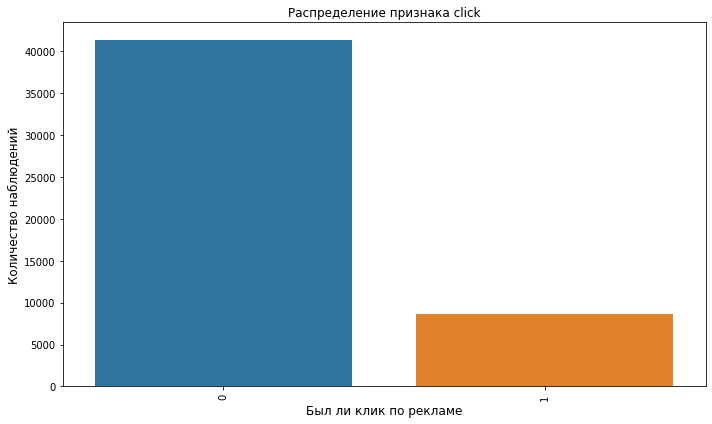

In [14]:
for feature, feature_name in categorial_features.items():
    
    grouped = df[feature].value_counts().reset_index().sort_values(by=feature, ascending=False)
    
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped, x='index', y=feature)
    
    plt.xticks(rotation=90)
    plt.title(f'Распределение признака {feature}')
    plt.ylabel('Количество наблюдений', fontsize=12)
    plt.xlabel(feature_name, fontsize=12)
    plt.tight_layout()
    plt.show()

Категориальные признаки: 
  - В признаках: site_category (тематическая категория веб-сайта), app_domain (домен рекламируемого приложения) и  app_category (категория рекламируемого приложения) явно видна правосторонняя ассиметрия в данных.
  - Наблюдния в признаках ml_feature_2 и ml_feature_7 распределены равномерно.
  - Целевая переменная click несбалансирована - количество отрицательных случаев ~4 раза больше положительных

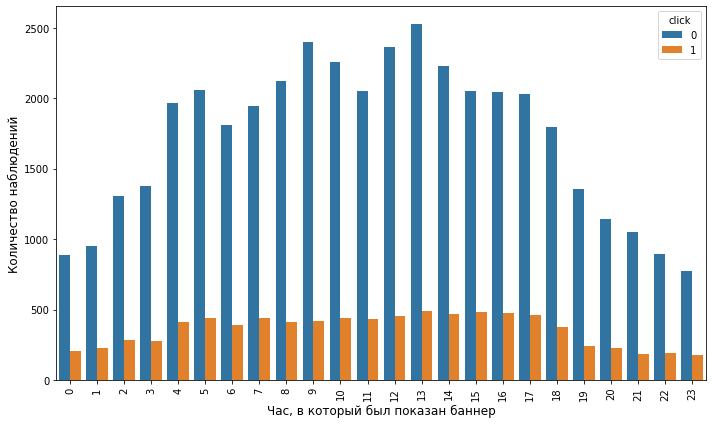

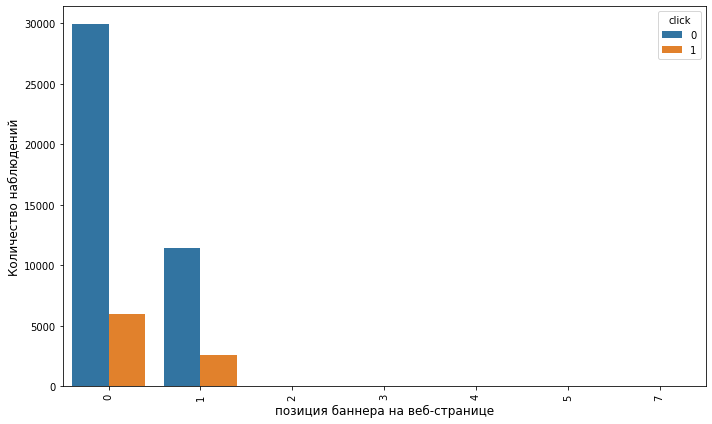

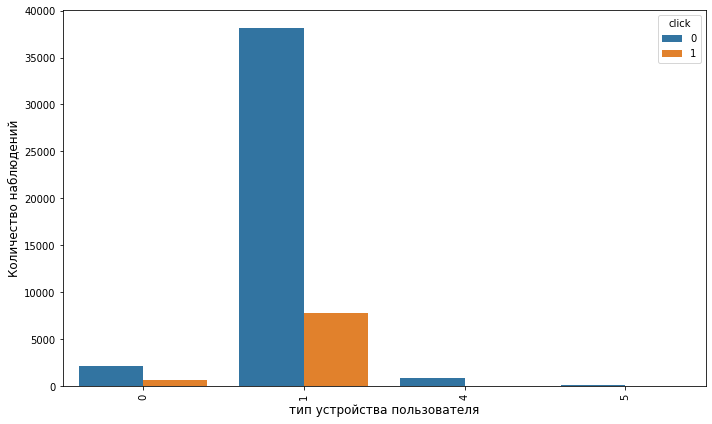

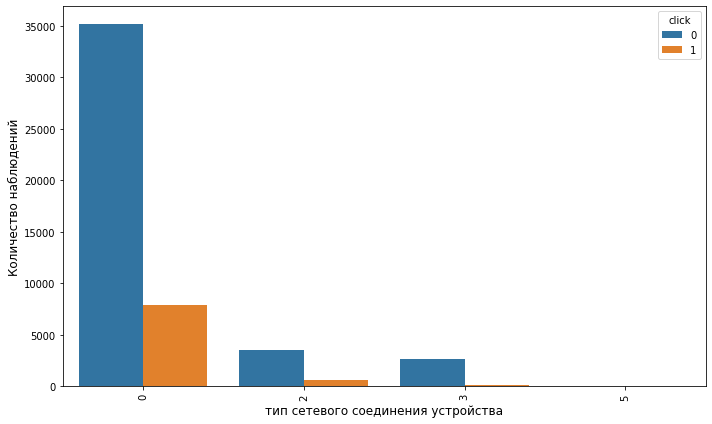

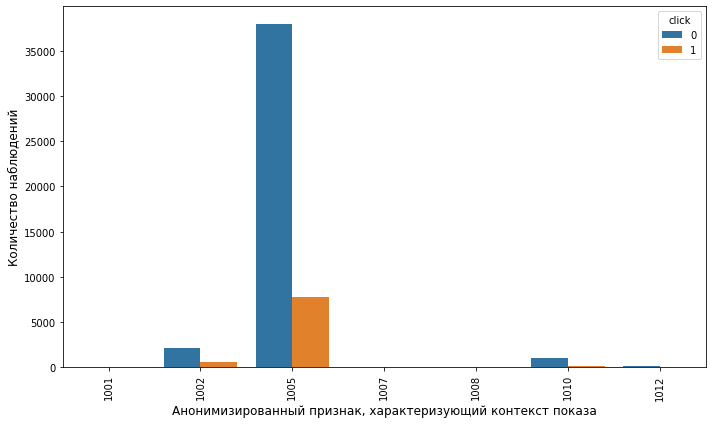

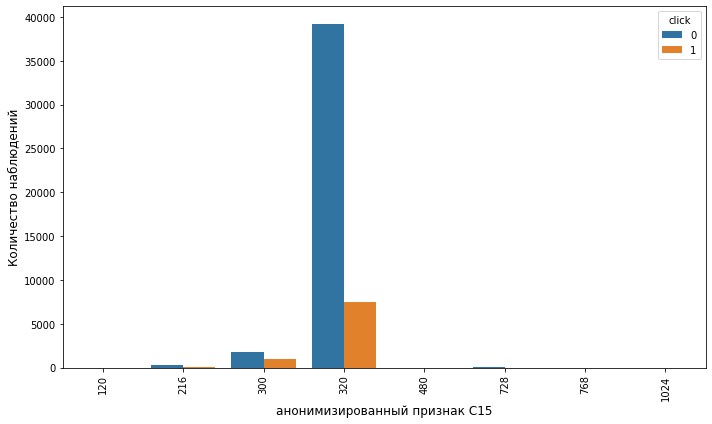

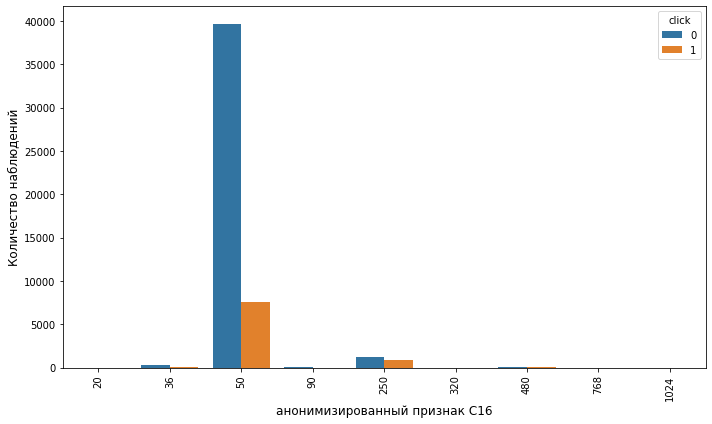

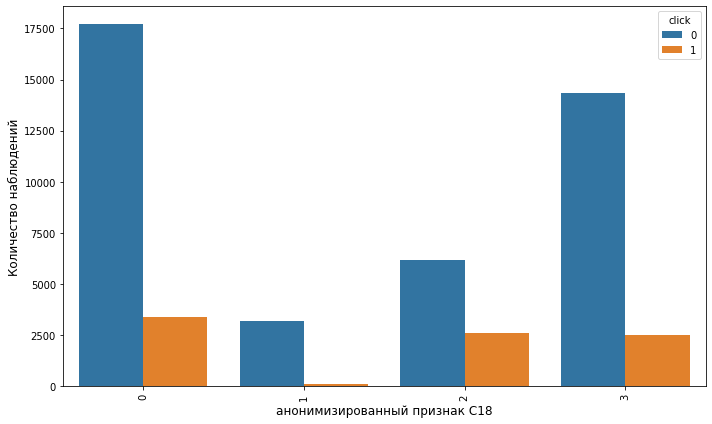

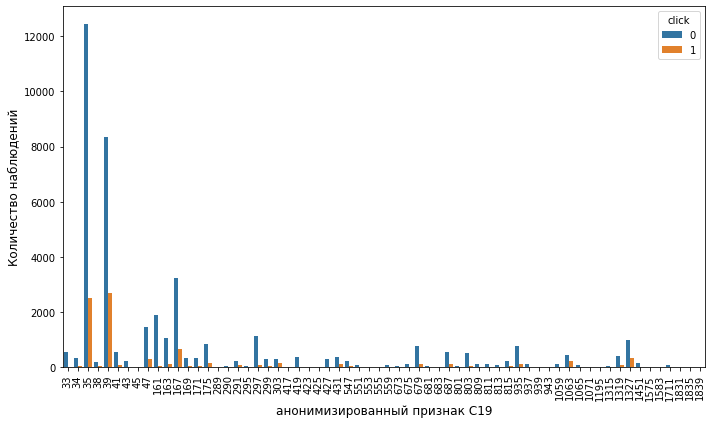

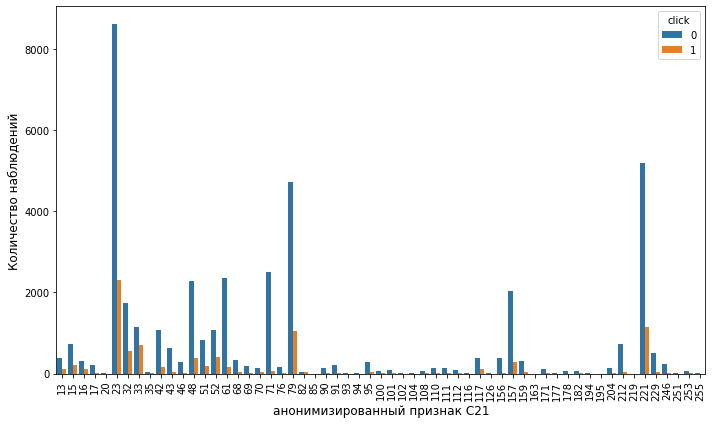

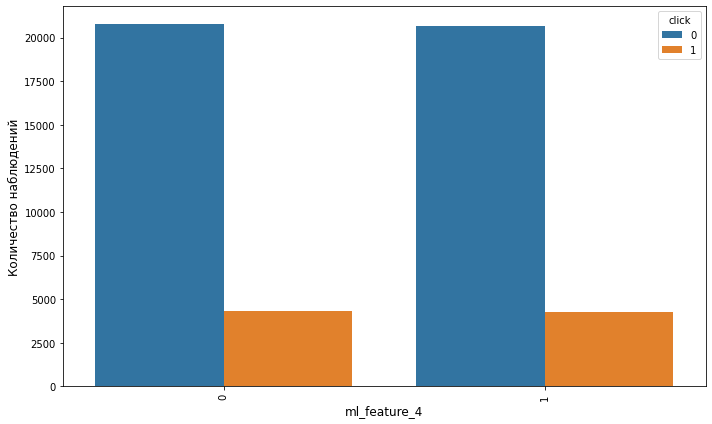

In [15]:
for feature, feature_name in discret_features.items():
    
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue='click')
    
    plt.xticks(rotation=90)
    plt.ylabel('Количество наблюдений', fontsize=12)
    plt.xlabel(feature_name, fontsize=12)
    plt.legend(title='click', loc='upper right')
    plt.tight_layout()
    plt.show()

Дискретные признаки:
  - Среди 7 возможных для размещения позиций для баннеров, действительно используется только 0 и 1 позиции
  - В типе устройства и типе сетевого соединения устройства также четко видно лидеры - 1 и 0 соответственно

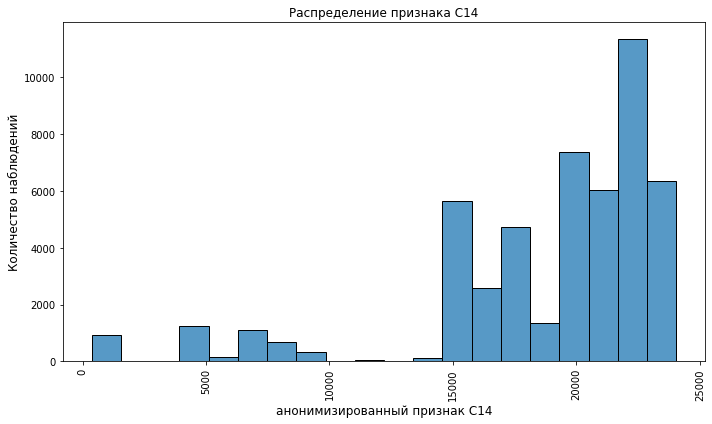

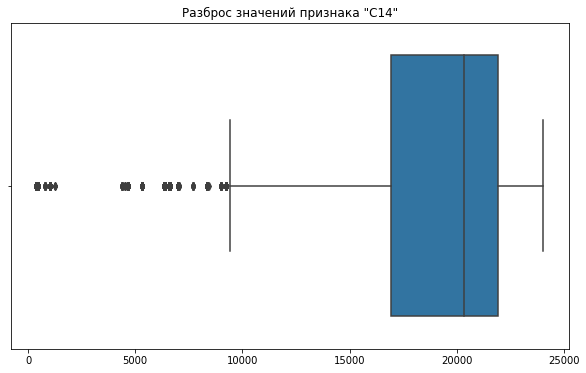

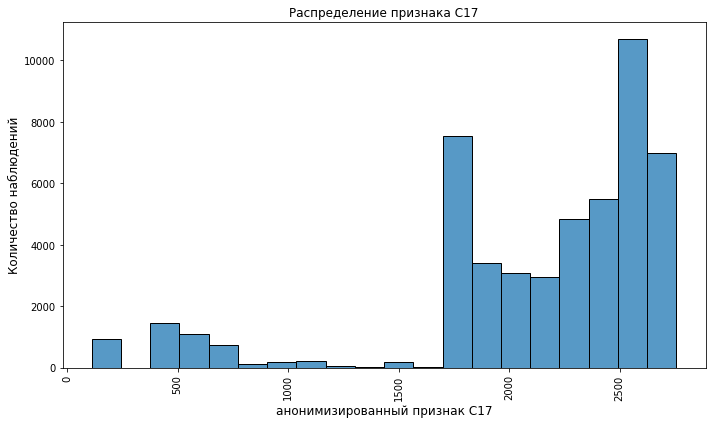

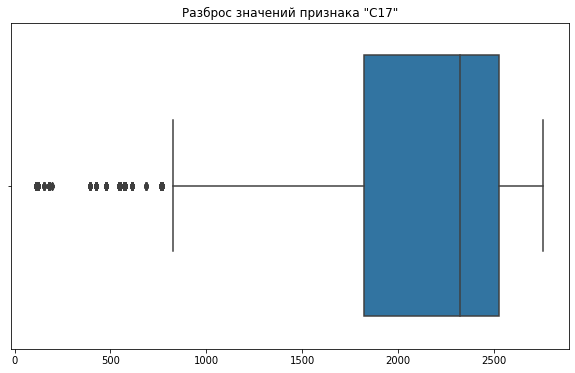

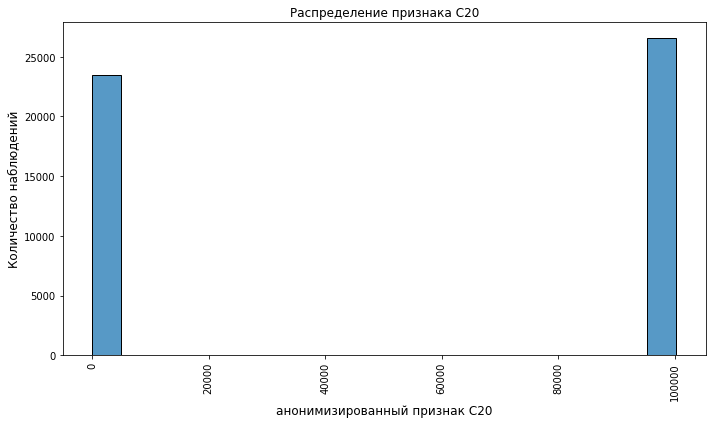

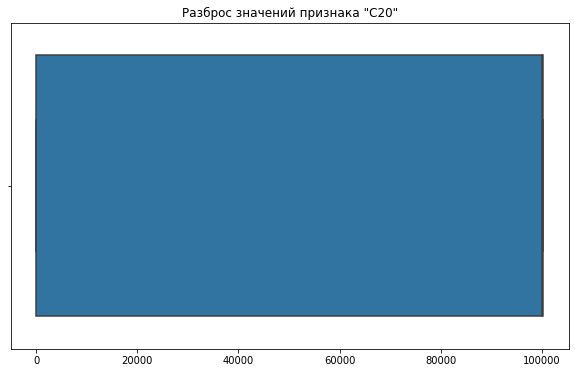

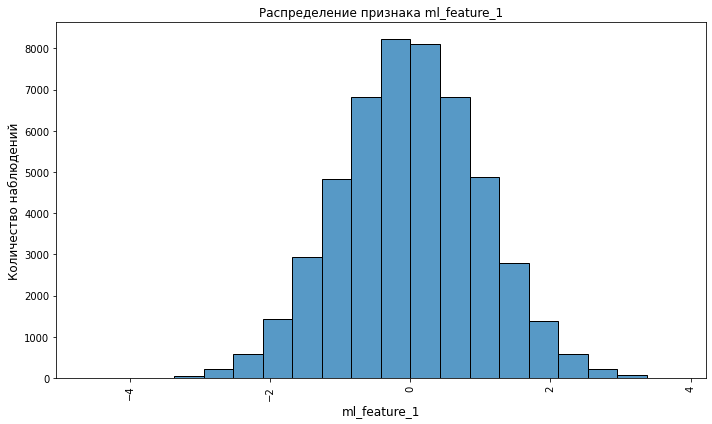

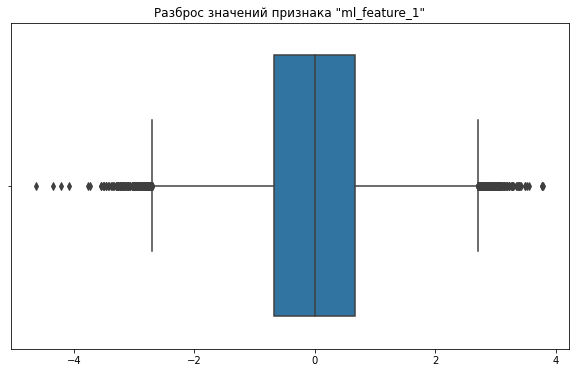

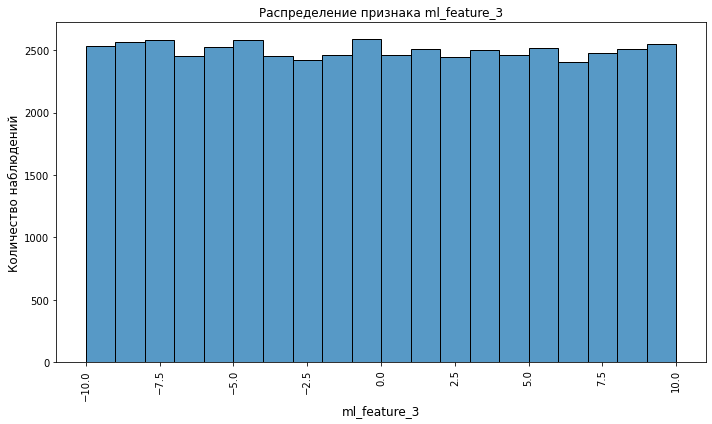

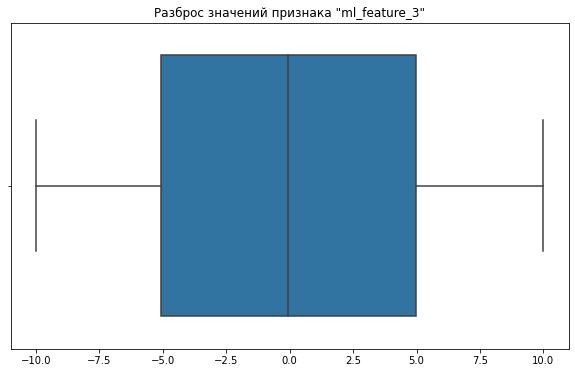

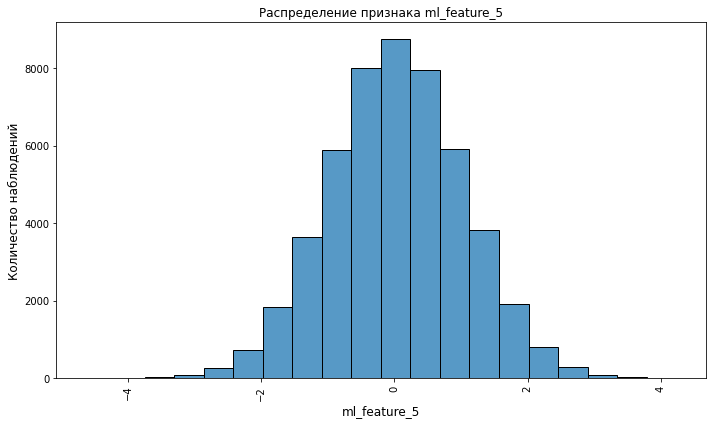

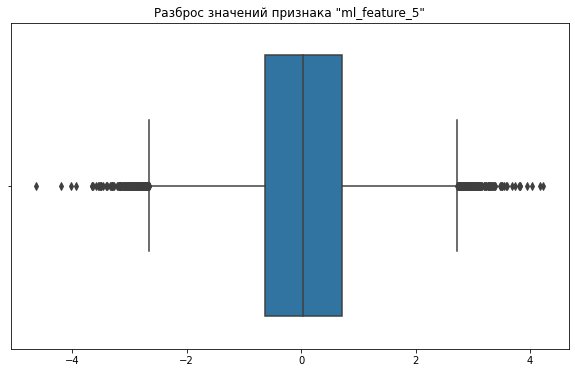

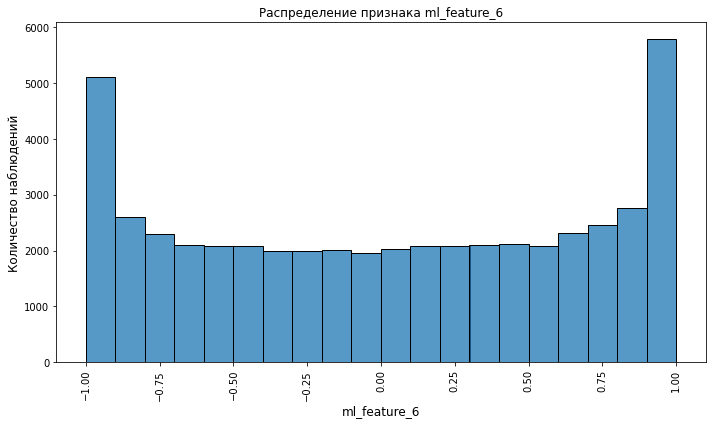

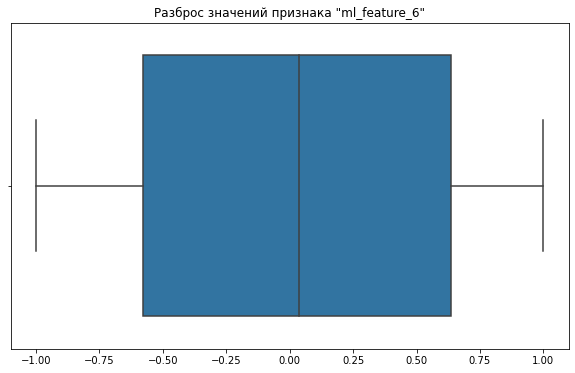

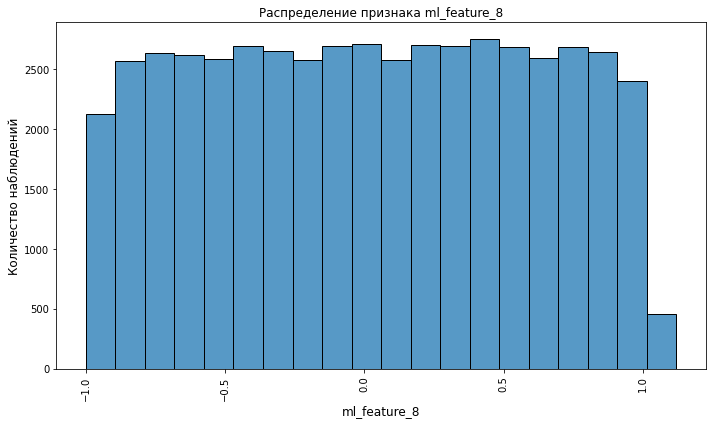

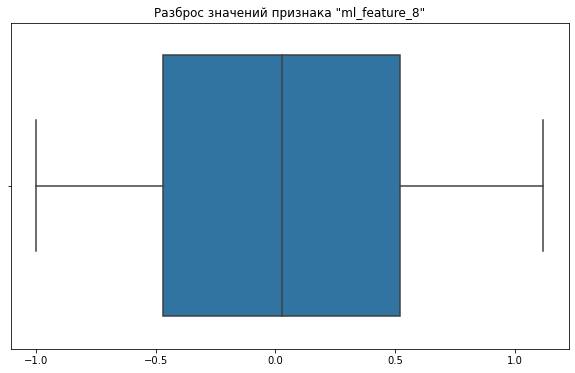

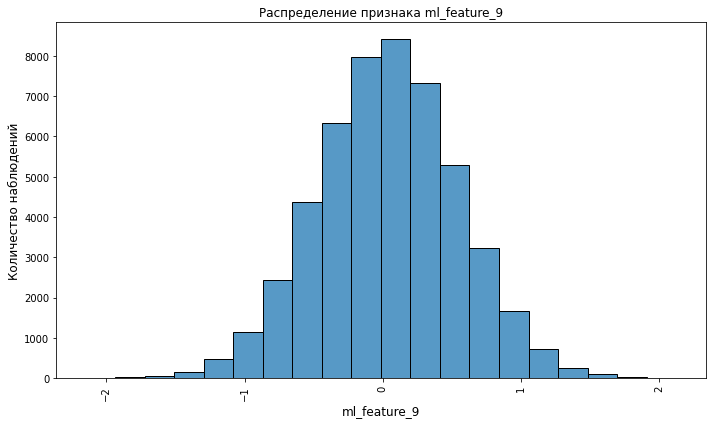

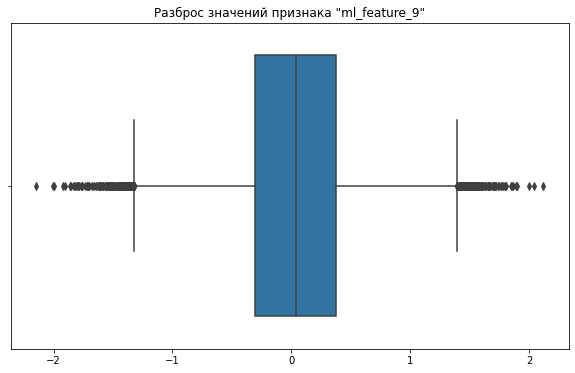

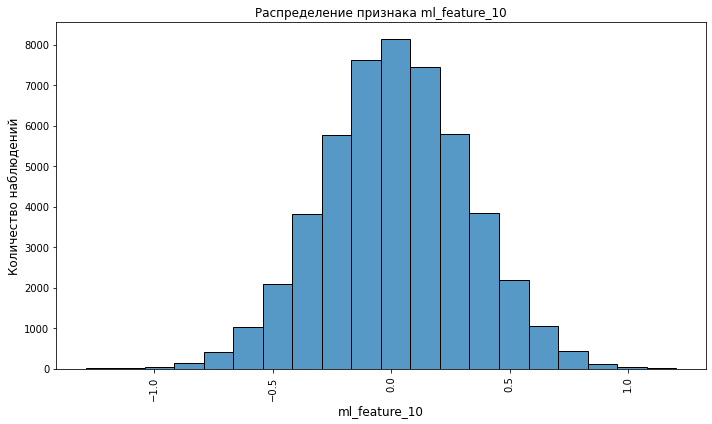

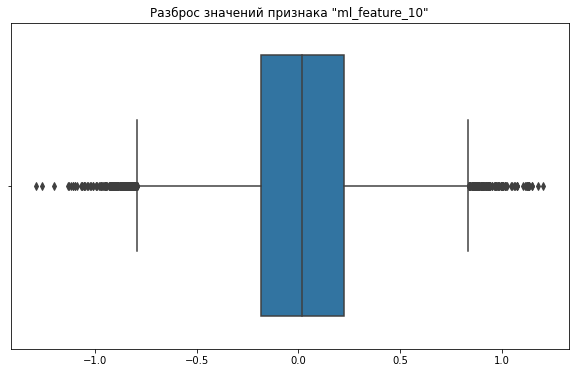

In [16]:
for feature, feature_name in numeric_features.items():
    
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=feature, bins=20)
    plt.xticks(rotation=90)
    plt.title(f'Распределение признака {feature}')
    plt.ylabel('Количество наблюдений', fontsize=12)
    plt.xlabel(feature_name, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=feature)
    plt.title(f'Разброс значений признака "{feature}"')
    plt.xlabel('')
    plt.show()

Числовые признаки:
  - Признаки ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 имеют нормальное распредление
  - В признаках C14, C17, ml_feature_1, ml_feature_5, ml_feature_9 и ml_feature_10 присутствуют выбросы, но в силу того, что эти данные анонимизированы и в них нет каких-то чрезмерно выделяющихся значений, обработка выбросов не производим

interval columns not set, guessing: ['click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


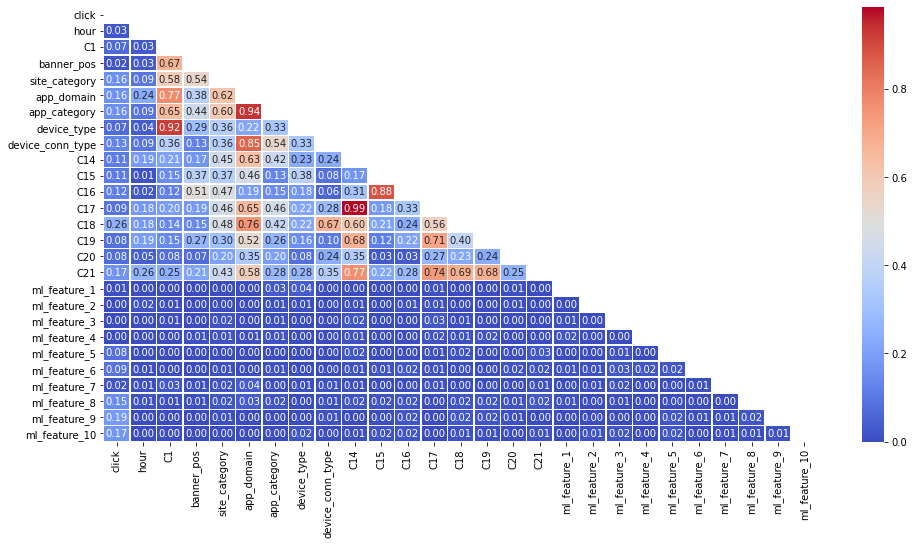

In [17]:
# Матрица корреляций
corr_data = df.phik_matrix()

plt.figure(figsize=(16, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.show()

Признаки для удаления после анализа корреляции:
  - C1 : сильная корреляция с device_type
  - app_domain : сильная корреляция с app_category
  - C14 : сильная корреляция с C17 и C21
  - C15 : сильная корреляция с C16 (оставили C16 потому что корреляция с целевой выше)
  - C17 : сильная корреляция с C19 и C21
  - C21 : сильная корреляция C18 и C19

In [18]:
df = df.drop(columns=[
    'C1',
    'app_domain',
    'C14',
    'C15',
    'C17',
    'C21'
])

<a id='3'></a>
## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [19]:
X = df.drop(columns='click')
y = df['click']

X_non_train, X_test, y_non_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y,
                                                    shuffle=True, random_state=RANDOM_SEED)

X_train, X_calib, y_train, y_calib = train_test_split(X_non_train, y_non_train, test_size=0.1111, stratify=y_non_train,
                                                    shuffle=True, random_state=RANDOM_SEED)

In [20]:
print(f"Количество строк в тренировочной выборке: {X_train.shape[0]}")
print(f"Количество строк в калибровочной выборке: {X_calib.shape[0]}")
print(f"Количество строк в тестовой выборке: {X_test.shape[0]}")
print()
print(f"Доля положительных 'click' в тренировочной выборке {round(y_train.sum() / y_train.shape[0] * 100, 1)}%")
print(f"Доля положительных 'click' в калибровочной выборке {round(y_calib.sum() / y_calib.shape[0] * 100, 1)}%")
print(f"Доля положительных 'click' в тестовой выборке {round(y_test.sum() / y_test.shape[0] * 100, 1)}%")

Количество строк в тренировочной выборке: 40000
Количество строк в калибровочной выборке: 5000
Количество строк в тестовой выборке: 5000

Доля положительных 'click' в тренировочной выборке 17.2%
Доля положительных 'click' в калибровочной выборке 17.2%
Доля положительных 'click' в тестовой выборке 17.2%


<a id='4'></a>
## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [21]:
def preprocess(categorial_features_onehot,
               categorial_features_target,
               numeric_features):

    preprocessor = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(drop='first',
                     handle_unknown='ignore', sparse_output=False), categorial_features_onehot),
            ('targetencoder', TargetEncoder(), categorial_features_target),
            ('num', StandardScaler(), numeric_features)
        ]
    )
    
    return preprocessor

  - Пропусков в данных нет, обрабатывать выбросы не нужно
  - Для категориальных данных с малой кардинальностью используется OneHotEncoder
  - Для категориальных данных с высокой кардинальностью используется TargetEncoder
  - Числовые данные масштабируются с помощью StandardScaler

<a id='5'></a>
## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [22]:
def remove_cols(df, cols):
    
    data = df.copy()
    try:
        for col in cols:
            data = data.drop(columns=col)
    except:
        ...
        
    return data

In [23]:
full_train = X_train.copy()
full_train['click'] = y_train.values

corr_data = full_train.phik_matrix()

threshold = 0.05
phik_click_correlations = corr_data['click'].drop('click')

print('\nИз-за низкой корреляции с целевой переменной будут удалены столбцы:\n')
print(phik_click_correlations[phik_click_correlations.values <= threshold])

cols_for_del_by_corr = phik_click_correlations[phik_click_correlations.values <= threshold].index.to_list()

# В трансформер
corr_cols_filter = FunctionTransformer(remove_cols, kw_args={'cols': cols_for_del_by_corr})

interval columns not set, guessing: ['hour', 'banner_pos', 'device_type', 'device_conn_type', 'C16', 'C18', 'C19', 'C20', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'click']

Из-за низкой корреляции с целевой переменной будут удалены столбцы:

hour            0.020991
banner_pos      0.019156
ml_feature_1    0.007840
ml_feature_2    0.005018
ml_feature_3    0.000000
ml_feature_4    0.004698
ml_feature_7    0.021790
Name: click, dtype: float64


In [24]:
categorial_features_onehot = ['C18', 'device_type',
                              'device_conn_type']

categorial_features_target = ['site_category', 'app_category']

numeric_features = ['C16',
    'C19', 'C20', 'ml_feature_5',
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9',
    'ml_feature_10']

preprocessor = preprocess(
    categorial_features_onehot=categorial_features_onehot,
    categorial_features_target=categorial_features_target,
    numeric_features=numeric_features
)

In [25]:
sfs_vt_pipe = Pipeline(steps=[
    ('cols_filter', corr_cols_filter),
    ('preprocessor', preprocessor),
    ('sfs', SFS(LogisticRegression(random_state=RANDOM_SEED), n_features_to_select=15,
         direction='backward', cv=2,
         scoring='average_precision', n_jobs = -1)),
    ('var_filter', VarianceThreshold(threshold=0.05))
    ])

sfs_vt_pipe.fit(X_train, y_train)

# названия признаков которые остались
col_names = list(sfs_vt_pipe[-3].get_feature_names_out())
ind =list(sfs_vt_pipe[-1].get_feature_names_out())
ind = [int(i.replace('x', '')) for i in ind]
selected_features = [col_names[i] for i in ind]

cols_for_del_by_sfs = list(set(col_names) - set(selected_features))

In [26]:
cols_filter = FunctionTransformer(remove_cols, kw_args={'cols': cols_for_del_by_sfs})

<a id='6'></a>
## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [29]:
pipelines = {
    'dummy' : Pipeline(steps=[
        ('classifier', DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)),
        ]),

    'logistic_regression' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('cols_filter', cols_filter),
        ('classifier', LogisticRegression(random_state=RANDOM_SEED)),
        ]),
    
    'svc' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('cols_filter', cols_filter),
        ('classifier', SVC(kernel='linear', probability=False, class_weight='balanced', random_state=RANDOM_SEED)),
        ])
}

In [30]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision' : 'precision',
    'recall' : 'recall',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'pr auc': 'average_precision'
}

for model in pipelines:
    start_time = time()
    cv_results = cross_validate(
        pipelines[model],
        X_train, y_train,
        cv=outer_cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    end_time = time()
    
    print(f"Время обучения и оценки (CV): {end_time - start_time:.2f} сек.")
    
    print(f"\n--- Средние Метрики Модели {model}---")
    for metric in scoring_metrics.keys():
        mean_value = np.mean(cv_results[f'test_{metric}'])
        std_value = np.std(cv_results[f'test_{metric}'])
        print(f"  Средний {metric}: {mean_value:.4f} (±{std_value:.4f})")
    print("-" * 55)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:15

Время обучения и оценки (CV): 0.16 сек.

--- Средние Метрики Модели dummy---
  Средний accuracy: 0.8279 (±0.0001)
  Средний precision: 0.0000 (±0.0000)
  Средний recall: 0.0000 (±0.0000)
  Средний roc_auc: 0.5000 (±0.0000)
  Средний f1: 0.0000 (±0.0000)
  Средний pr auc: 0.1721 (±0.0001)
-------------------------------------------------------
Время обучения и оценки (CV): 9.79 сек.

--- Средние Метрики Модели logistic_regression---
  Средний accuracy: 0.8335 (±0.0012)
  Средний precision: 0.6173 (±0.0254)
  Средний recall: 0.0853 (±0.0056)
  Средний roc_auc: 0.7220 (±0.0040)
  Средний f1: 0.1498 (±0.0091)
  Средний pr auc: 0.3710 (±0.0124)
-------------------------------------------------------
Время обучения и оценки (CV): 286.98 сек.

--- Средние Метрики Модели svc---
  Средний accuracy: 0.6614 (±0.0039)
  Средний precision: 0.2865 (±0.0046)
  Средний recall: 0.6494 (±0.0103)
  Средний roc_auc: 0.7212 (±0.0044)
  Средний f1: 0.3976 (±0.0063)
  Средний pr auc: 0.3699 (±0.0127)
-------

Выводы:
  - По одной из ключевых метрик PR-AUC обе обученые модели Логистическая регрессия и SVM показали результаты в ~2 раза лучше чем Dummy модель (0.37 против 0.17) поэтому обе протестируем на тестовой выборке
  - Средний F1 у SVM модели в ~2.7 раза лучше, чем у Логистической регрессии (0.4 против 0.15)
  - Показатель ROC-AUC для обоих обученных моделей получился хорошим, но данный показатель плохо отражает реальную ситуацию в несбалансированных данных

<a id='7'></a>
## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [31]:
param_grid_svc = {
    'classifier__C': [1, 10, 100],
    'classifier__gamma': ['scale', 'auto']
}

param_grid_linreg = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__class_weight': ['balanced', None]
}

In [32]:
def optimize_model_grid(model, X, y, param_grid, n_splits=3):
    
    start_time = time()

    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    search = GridSearchCV(
        model,
        param_grid,
        cv=kfold,
        scoring='average_precision',
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    search.fit(X, y)
    
    results_df = pd.DataFrame(search.cv_results_)
    
    results_df = results_df.sort_values('rank_test_score')
    
    display_cols = ['rank_test_score', 'mean_test_score', 'std_test_score']
    
    display_cols = [col for col in display_cols if col in results_df.columns]
    
    summary = results_df[display_cols].head(10).copy()
    
    end_time = time()
    
    print(f"\nВремя подбора гиперпараметров: {end_time - start_time:.2f} сек.\n")
    
    return search.best_estimator_, search.best_params_, summary


In [33]:
best_linreg_model, best_linreg_params, results_linreg_table = optimize_model_grid(
    model=pipelines['logistic_regression'], 
    X=X_train, 
    y=y_train, 
    param_grid=param_grid_linreg
)

print(f'Лучшая модель: \n{best_linreg_model}\n')
print(f'Лучшие гиперпараметры: \n{best_linreg_params}')

results_linreg_table

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Время подбора гиперпараметров: 65.71 сек.

Лучшая модель: 
Pipeline(steps=[('corr_cols_filter',
                 FunctionTransformer(func=<function remove_cols at 0x7fbdf4fd05e0>,
                                     kw_args={'cols': ['hour', 'banner_pos',
                                                       'ml_feature_1',
                                                       'ml_feature_2',
                                                       'ml_feature_3',
                                                       'ml_feature_4',
                                                       'ml_feature_7']})),
                ('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                              

,rank_test_score,mean_test_score,std_test_score
18,1,0.369796,0.005492
19,2,0.369721,0.005636
14,3,0.369665,0.005641
15,4,0.369640,0.005743
13,5,0.369639,0.005984
17,6,0.369553,0.005912
12,7,0.369438,0.006196
16,8,0.369393,0.006140
8,9,0.368730,0.006562
9,10,0.368637,0.006587


In [34]:
best_svc_model, best_svc_params, results_svc_table = optimize_model_grid(
    model=pipelines['svc'], 
    X=X_train, 
    y=y_train, 
    param_grid=param_grid_svc
)

print(f'Лушая модель: \n{best_svc_model}')
print(f'Лучшие гиперпараметры: \n{best_svc_params}')

results_svc_table

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Время подбора гиперпараметров: 4790.02 сек.

Лушая модель: 
Pipeline(steps=[('corr_cols_filter',
                 FunctionTransformer(func=<function remove_cols at 0x7fbdf4fd05e0>,
                                     kw_args={'cols': ['hour', 'banner_pos',
                                                       'ml_feature_1',
                                                       'ml_feature_2',
                                                       'ml_feature_3',
                                                       'ml_feature_4',
                                                       'ml_feature_7']})),
                ('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                              

,rank_test_score,mean_test_score,std_test_score
2,1,0.368706,0.005702
4,2,0.368696,0.005749
0,3,0.368693,0.005639
1,4,0.368600,0.005582
5,5,0.368528,0.005786
3,6,0.368457,0.005697


долго обучается для SVM
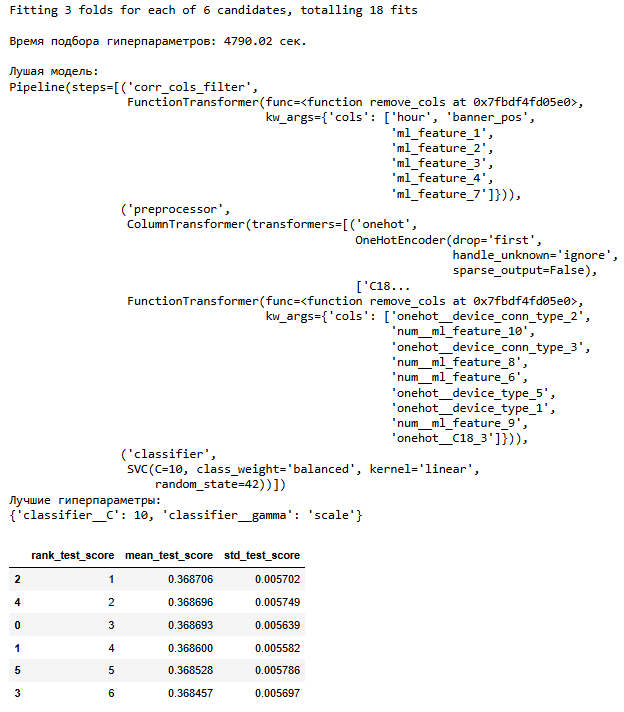

  - Подбор гиперпараметров для Логистической регрессии не дало никаких улучшений
  - Подбор гиперпараметров для SVM модели также не дало никаких улучшений

<a id='8'></a>
## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [35]:
def evaluate_model_cv(model, X, y, N_FOLDS = 5):
    kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    scoring = {
        'precision' : make_scorer(precision_score, zero_division=0),
        'recall' : 'recall',
        'f1' : 'f1',
        'average_precision': 'average_precision', 
        'roc_auc': 'roc_auc',
        'brier': make_scorer(brier_score_loss)
    }

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring=scoring,
        return_train_score=False
    )

    print(f"Результаты модели {model['classifier']}:")
    print(f"CV Precision: {cv_results['test_precision'].mean():.4f}")
    print(f"CV Recall: {cv_results['test_recall'].mean():.4f}")
    print(f"CV F1: {cv_results['test_f1'].mean():.4f}")
    print(f"CV ROC-AUC: {cv_results['test_roc_auc'].mean():.4f}")
    print(f"CV PR-AUC: {cv_results['test_average_precision'].mean():.4f}")
    print(f"CV Brier Score: {cv_results['test_brier'].mean():.4f}")


In [36]:
evaluate_model_cv(model=best_linreg_model, X=X_test, y=y_test)

Результаты модели LogisticRegression(C=10, random_state=42):
CV Precision: 0.5422
CV Recall: 0.0686
CV F1: 0.1216
CV ROC-AUC: 0.7092
CV PR-AUC: 0.3649
CV Brier Score: 0.1704


In [37]:
# Синизил N_FOLDS до 3 чтобы не грузилось очень долго
evaluate_model_cv(model=best_svc_model, X=X_test, y=y_test, N_FOLDS=3)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Результаты модели SVC(C=10, class_weight='balanced', kernel='linear', random_state=42):
CV Precision: 0.2869
CV Recall: 0.6326
CV F1: 0.3946
CV ROC-AUC: 0.7092
CV PR-AUC: 0.3629
CV Brier Score: 0.3336


  - Одна из ключевых метрик pr-auc на тестовой выборке у Логистической регрессии и у модели SVM не изменилась относительно тренировчной выборке - значит, модель не переобучилась
  - Также нужно отметить более высокую оценку Бриера у модели SVM (0.33) по сравнению с 0.17 у Логистической регрессии

In [87]:
# Получение названий фичей из пайплайна
col_names = list(best_svc_model[-3].get_feature_names_out())
ind =list(sfs_vt_pipe .named_steps['var_filter'].get_feature_names_out())
ind = [int(i.replace('x', '')) for i in ind]
selected_feature_names = [col_names[i] for i in ind]


coefs = best_svc_model.named_steps['classifier'].coef_[0]
intercept = best_svc_model.named_steps['classifier'].intercept_[0]

print('Коэффициенты признаков:')
for i in range(len(selected_feature_names)):
    print(f"{selected_feature_names[i]} : {np.abs(coefs[i]):.2f}")
print(f"Свободный коэффициент: {float(intercept):.2f}\n")

Коэффициенты признаков:
onehot__C18_1 : 0.96
onehot__C18_2 : 0.67
onehot__device_type_4 : 0.02
onehot__device_conn_type_5 : 0.29
targetencoder__site_category : 0.68
targetencoder__app_category : 0.57
num__C16 : 0.00
num__C19 : 0.15
num__C20 : 1.09
num__ml_feature_5 : 1.93
Свободный коэффициент: -1.13



In [89]:
# Получение названий фичей из пайплайна
col_names = list(best_linreg_model[-3].get_feature_names_out())
ind =list(sfs_vt_pipe .named_steps['var_filter'].get_feature_names_out())
ind = [int(i.replace('x', '')) for i in ind]
selected_feature_names = [col_names[i] for i in ind]


coefs = best_linreg_model.named_steps['classifier'].coef_[0]
intercept = best_linreg_model.named_steps['classifier'].intercept_[0]

print('Коэффициенты признаков:')
for i in range(len(selected_feature_names)):
    print(f"{selected_feature_names[i]} : {np.abs(coefs[i]):.2f}")
print(f"Свободный коэффициент: {float(intercept):.2f}\n")

Коэффициенты признаков:
onehot__C18_1 : 1.34
onehot__C18_2 : 0.57
onehot__device_type_4 : 0.02
onehot__device_conn_type_5 : 0.30
targetencoder__site_category : 0.78
targetencoder__app_category : 0.80
num__C16 : 0.06
num__C19 : 0.36
num__C20 : 0.38
num__ml_feature_5 : 2.42
Свободный коэффициент: -2.46



Для обоих моделей наиболее важными признаками по коэффициентам являются:
  - ml_feature_5
  - анонимизированный признак C18
  - анонимизированный признак C20
  - тематическая категория веб-сайта (site_category)
  - категория рекламируемого приложения (app_category)

<a id='9'></a>
## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

In [90]:
def sigmoid_numpy(x):
    return 1 / (1 + np.exp(-x)) 

def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.abs(bin_conf - bin_acc) * np.sum(mask) / n
    return ece

def calculate_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    max_error = 0
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf =  np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            max_error = max(max_error, np.abs(bin_conf - bin_acc))
    return max_error

In [91]:
# Dummy предсказания
pipelines['dummy'].fit(X_train, y_train)
y_prob_dummy = pipelines['dummy'].predict_proba(X_test)[:, 1]

# сырые значения
raw_scores = best_svc_model.decision_function(X_test)
# предсказания на сырых данных
y_prob_svc_raw = sigmoid_numpy(raw_scores)


# предсказания логистической регрессии
y_prob_regr = best_linreg_model.predict_proba(X_test)[:, 1]


# калибровка
frozen_svm = FrozenEstimator(best_svc_model)
svm_calibrated = CalibratedClassifierCV(
    frozen_svm, 
    method='isotonic',
    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_SEED
    )
)

svm_calibrated.fit(X_calib, y_calib)
# калибровнные предсказания
y_prob_svc_calibrated = svm_calibrated.predict_proba(X_test)[:, 1]

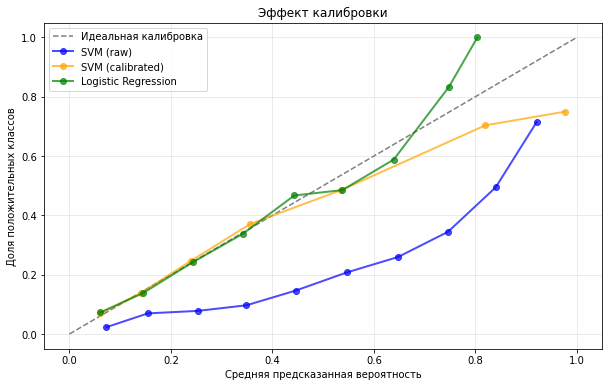

In [92]:
fop_orig_raw, mpv_orig_raw = calibration_curve(y_test, y_prob_svc_raw, 
                                       n_bins=10)

fop_orig_calibrated, mpv_orig_calibrated = calibration_curve(y_test, y_prob_svc_calibrated, 
                                       n_bins=10)

fop_orig_regr, mpv_orig_regr = calibration_curve(y_test, y_prob_regr, 
                                       n_bins=10)


# График
display_setup = ["blue", "orange", "green"]

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Идеальная калибровка')

plt.plot(mpv_orig_raw, fop_orig_raw, marker='o', linewidth=2, 
         label="SVM (raw)", alpha=0.7, color=display_setup[0])

plt.plot(mpv_orig_calibrated, fop_orig_calibrated, marker='o', linewidth=2, 
         label="SVM (calibrated)", alpha=0.7, color=display_setup[1])

plt.plot(mpv_orig_regr, fop_orig_regr, marker='o', linewidth=2, 
         label="Logistic Regression", alpha=0.7, color=display_setup[2])

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Эффект калибровки')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<a id='10'></a>
## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [93]:
ece_before_calib = calculate_ece(y_test, y_prob_svc_raw)
mce_before_calib = calculate_mce(y_test, y_prob_svc_raw)

ece_after_calib = calculate_ece(y_test, y_prob_svc_calibrated)
mce_after_calib = calculate_mce(y_test, y_prob_svc_calibrated)

ece_log_reg = calculate_ece(y_test, y_prob_regr)
mce_log_reg = calculate_mce(y_test, y_prob_regr)


data = {
    'Метод': ['SVC (до калибровки)', 'SVC (после калибровки)', 'Логистическая регрессия'],
    'ECE': [ece_before_calib, ece_after_calib, ece_log_reg],
    'MCE': [mce_before_calib, mce_after_calib, mce_log_reg]
}

df = pd.DataFrame(data)
df

,Метод,ECE,MCE
0,SVC (до калибровки),0.272197,0.401592
1,SVC (после калибровки),0.008154,0.227495
2,Логистическая регрессия,0.008965,0.195909


Выводы по калибровке:
  - Калибровка модели SVM существенно снизила ECE (в 30 раз)
  - В результате калибровки MCE также снизилось с 0.4 до 0.22
  - Откалиброваная SVM модель все равно немного уступает Логистической регрессии

<a id='11'></a>
## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

In [94]:
def calculate_all_metrics(y_true, y_pred_proba, model_name):
    
    if len(y_pred_proba.shape) == 2 and y_pred_proba.shape[1] == 2:
        y_pred_proba_pos = y_pred_proba[:, 1]
    else:
        y_pred_proba_pos = y_pred_proba
    
    y_pred = (y_pred_proba_pos >= 0.5).astype(int)
    
    metrics = {
        'Model': model_name,
        'ROC-AUC': round(roc_auc_score(y_true, y_pred_proba_pos), 4),
        'PR-AUC': round(average_precision_score(y_true, y_pred_proba_pos), 4),
        'Log Loss': round(log_loss(y_true, y_pred_proba_pos), 4),
        'Brier Score': round(brier_score_loss(y_true, y_pred_proba_pos), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
    }
    
    return metrics


svc_calib_metrics = calculate_all_metrics(y_test, y_prob_svc_calibrated, 'SVC_calibrated')
svc_base_metrics = calculate_all_metrics(y_test, y_prob_svc_raw, 'SVC_base')
logreg_metrics = calculate_all_metrics(y_test, y_prob_regr, 'Logistic_Regression')
dummy_metrics = calculate_all_metrics(y_test, y_prob_dummy, 'Dummy_Model')

final_df = pd.DataFrame(columns=['Model', 'PR-AUC', 'Log Loss', 'Brier Score', 'ROC-AUC', 'Recall', 'Precision'])

final_df = pd.concat([final_df,
                      pd.DataFrame([svc_calib_metrics]),
                      pd.DataFrame([svc_base_metrics]),
                      pd.DataFrame([logreg_metrics]),
                      pd.DataFrame([dummy_metrics])],
                     ignore_index=True)

In [95]:
print("Характеристики откалиброванной SVC модели:")
print(svm_calibrated.estimator.estimator.named_steps['classifier'].get_params())
print('\n', '*' * 60, '\n')
print("Характеристики модели логистической регрессии:")
print(best_linreg_model.named_steps['classifier'].get_params())

final_df

Характеристики откалиброванной SVC модели:
{'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

 ************************************************************ 

Характеристики модели логистической регрессии:
{'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


,Model,PR-AUC,Log Loss,Brier Score,ROC-AUC,Recall,Precision
0,SVC_calibrated,0.3447,0.4244,0.1294,0.7103,0.0849,0.5448
1,SVC_base,0.3631,0.6136,0.2127,0.7125,0.6512,0.2860
2,Logistic_Regression,0.3638,0.4167,0.1289,0.7117,0.0744,0.5565
3,Dummy_Model,0.1720,6.1995,0.1720,0.5000,0.0000,0.0000


  - Логистическая регрессия и откалиброванная модель SVC почти не имеют различий в ключевых метриках PR-AUC, Log Loss и Brier Score, но в силу того, что модель логистической регрессии работает в разы быстрее я бы рекомендовал использвать ее
  - Калибровка модели SVM позволила улучшить показатели Log Loss и Brier Score, но при этом незначительно снизила PR-AUC
  - Полученные модели в ~2 раза превосходят базовую модель (Dummy), но по моему мнению все еще недостаточно хорошо для их использования в продакшене

<a id='12'></a>
## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [96]:
joblib.dump(svm_calibrated, 'svm_model.joblib')
joblib.dump(best_linreg_model, 'logreg_model.joblib')

['logreg_model.joblib']

In [97]:
logreg_model = joblib.load('logreg_model.joblib')
svc_model = joblib.load('svm_model.joblib')

In [98]:
if logreg_model.predict_proba(X_test)[:, 1].all() == y_prob_regr.all():
    print('Модели одинаковые')

Модели одинаковые


In [99]:
if svc_model.predict_proba(X_test)[:, 1].all() == y_prob_svc_calibrated.all():
    print('Модели одинаковые')

Модели одинаковые
